# Keypoint Combining – MediaPipe & MoveNet

1. MediaPipe visibility ≥ 0.6 → use MediaPipe
2. MoveNet confidence ≥ 0.6, not interpolated → use MoveNet
3. Else → missing (NaN), rescued by GPR in later step

In [42]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import re

IN_DIR          = Path('../data/processed/keypoints_interpolated_boundary')
DOWN_IN_DIR     = Path('../data/processed/keypoints_interpolated_down_boundary')
CROPPED_DIR     = Path('../data/processed/keypoints_cropped')
DOWN_CROPPED_DIR = Path('../data/processed/keypoints_cropped_down')
VIDEO_DIR       = Path('../data/Utvalda filminspelningar för IRAF analys/Dec 2025 sit-stå och stå-sitt')
OUT_CSV         = Path('../data/processed/keypoints_combined')
DOWN_OUT_CSV    = Path('../data/processed/keypoints_combined_down')
OUT_VIDEO       = Path('../data/processed/keypoints_combined_videos')
DOWN_OUT_VIDEO  = Path('../data/processed/keypoints_combined_videos_down')

FPS            = 50
THRESHOLD_HIGH = 0.6
THRESHOLD_LOW  = 0.3

time_dict = {
    '028': (9.90,  11.77), '030': (5.80,  7.63),
    '045': (6.54,   7.98), '047': (7.03,  8.91),
    '059': (6.65,   9.11), '061': (6.00,  9.00),
    '074': (6.07,   7.27), '076': (5.00,  8.00),
    '091': (6.39,   7.61), '093': (5.86,  7.67),
}

stand_to_sit_time_dict = {
    '028': (11.87, 12.87), '030': (8.07,  11.56),
    '045': (7.94,   9.26), '047': (9.20,  12.30),
    '059': (9.11,  11.06), '061': (10.57, 13.41),
    '074': (7.27,   8.20), '076': (8.27,  10.84),
    '091': (7.56,   8.18), '093': (8.50,  11.19),
}

JOINTS = [
    'nose',
    'left_shoulder', 'right_shoulder',
    'left_elbow',    'right_elbow',
    'left_wrist',    'right_wrist',
    'left_hip',      'right_hip',
    'left_knee',     'right_knee',
    'left_ankle',    'right_ankle',
]

COLOR_MEDIAPIPE = (255, 80,  80)
COLOR_MOVENET   = (80,  200, 80)
COLOR_GPR       = (0,   165, 255)

OUT_CSV.mkdir(parents=True, exist_ok=True)
DOWN_OUT_CSV.mkdir(parents=True, exist_ok=True)
OUT_VIDEO.mkdir(parents=True, exist_ok=True)
DOWN_OUT_VIDEO.mkdir(parents=True, exist_ok=True)

## Combining function

In [43]:
def combine_keypoints(df_mp, df_mn):
    combined = df_mp.copy()

    for joint in JOINTS:
        mp_vis    = df_mp[f'{joint}_visibility'].values
        mn_conf   = df_mn[f'{joint}_confidence'].values
        mn_interp = df_mn[f'{joint}_interpolated'].values if f'{joint}_interpolated' in df_mn.columns else np.ones(len(df_mn), dtype=bool)

        mp_missing  = mp_vis < THRESHOLD_HIGH
        mn_good     = (mn_conf >= THRESHOLD_HIGH) & (~mn_interp.astype(bool))
        use_movenet = mp_missing & mn_good

        for coord in ['x', 'y']:
            combined.loc[use_movenet, f'{joint}_{coord}'] = df_mn.loc[use_movenet, f'{joint}_{coord}'].values

        combined[f'{joint}_source'] = 'mediapipe'
        combined.loc[use_movenet, f'{joint}_source'] = 'movenet'

        still_missing = mp_missing & ~mn_good
        combined.loc[still_missing, f'{joint}_source'] = 'missing'
        combined.loc[still_missing, f'{joint}_x'] = np.nan
        combined.loc[still_missing, f'{joint}_y'] = np.nan

    return combined

## Combine and save

In [44]:
for in_dir, out_csv, label in [
    (IN_DIR, OUT_CSV, 'sit-to-stand'),
    (DOWN_IN_DIR, DOWN_OUT_CSV, 'stand-to-sit'),
]:
    print(f'\n=== {label} ===')
    for mp_path in sorted((in_dir / 'mediapipe_norm').glob('*.csv')):
        video_id = mp_path.stem.replace('_mediapipe_norm', '')
        out_path = out_csv / f'{video_id}.csv'

        if out_path.exists():
            print(f'{video_id}: already exists, skipping')
            continue

        mn_path = in_dir / 'movenet' / f'{video_id}_movenet.csv'
        if not mn_path.exists():
            print(f'  no MoveNet match for {video_id}, skipping')
            continue

        df_mp = pd.read_csv(mp_path)
        df_mn = pd.read_csv(mn_path)

        n           = min(len(df_mp), len(df_mn))
        df_combined = combine_keypoints(df_mp.iloc[:n].reset_index(drop=True),
                                        df_mn.iloc[:n].reset_index(drop=True))

        df_combined.to_csv(out_path, index=False)
        print(f'{video_id}: {n} frames saved')


=== sit-to-stand ===
DJI_20250425092743_0028_D: already exists, skipping
DJI_20250425093100_0030_D: already exists, skipping
DJI_20250425104507_0045_D: already exists, skipping
DJI_20250425104804_0047_D: already exists, skipping
DJI_20250425112502_0059_D: already exists, skipping
DJI_20250425112749_0061_D: already exists, skipping
DJI_20250425120835_0074_D: already exists, skipping
DJI_20250425121226_0076_D: already exists, skipping
DJI_20250425125202_0091_D: already exists, skipping
DJI_20250425125448_0093_D: already exists, skipping

=== stand-to-sit ===
DJI_20250425092743_0028_D: 50 frames saved
DJI_20250425093100_0030_D: 175 frames saved
DJI_20250425104507_0045_D: 67 frames saved
DJI_20250425104804_0047_D: 156 frames saved
DJI_20250425112502_0059_D: 98 frames saved
DJI_20250425112749_0061_D: 142 frames saved
DJI_20250425120835_0074_D: 47 frames saved
DJI_20250425121226_0076_D: 129 frames saved
DJI_20250425125202_0091_D: 32 frames saved
DJI_20250425125448_0093_D: 135 frames saved


## Missing joints before GPR

In [45]:
missing_before_all = {}

for out_csv, label in [(OUT_CSV, 'sit-to-stand'), (DOWN_OUT_CSV, 'stand-to-sit')]:
    before_rows = []
    for csv_path in sorted(out_csv.glob('*.csv')):
        df = pd.read_csv(csv_path)
        for joint in JOINTS:
            src_col = f'{joint}_source'
            if src_col not in df.columns:
                continue
            counts = df[src_col].value_counts()
            before_rows.append({
                'video':          csv_path.stem,
                'joint':          joint,
                'missing_before': counts.get('missing', 0),
                'total_frames':   len(df),
            })

    missing_before = pd.DataFrame(before_rows, columns=['video', 'joint', 'missing_before', 'total_frames'])
    missing_before_all[label] = missing_before
    total_before = missing_before['missing_before'].sum()

    print(f'\n=== {label} ===')
    print(f'Missing before GPR: {total_before} frames')
    only_missing = missing_before[missing_before['missing_before'] > 0][['video', 'joint', 'missing_before', 'total_frames']]
    print(only_missing.to_string(index=False))


=== sit-to-stand ===
Missing before GPR: 0 frames
Empty DataFrame
Columns: [video, joint, missing_before, total_frames]
Index: []

=== stand-to-sit ===
Missing before GPR: 363 frames
                    video       joint  missing_before  total_frames
DJI_20250425092743_0028_D right_elbow               9            50
DJI_20250425092743_0028_D right_wrist              34            50
DJI_20250425093100_0030_D right_elbow              39           175
DJI_20250425104507_0045_D right_elbow              29            67
DJI_20250425104507_0045_D right_wrist              50            67
DJI_20250425104804_0047_D right_elbow              50           156
DJI_20250425112502_0059_D right_elbow               3            98
DJI_20250425112502_0059_D right_wrist              28            98
DJI_20250425112749_0061_D right_elbow               5           142
DJI_20250425112749_0061_D right_wrist               5           142
DJI_20250425120835_0074_D right_elbow               1            47


## GPR Rescue, conf 0.3-0.6

For missing joints:
1. Copy coords from `keypoints_cropped` if conf 0.3-0.6 → flag `low_confidence`
2. Fit GP per joint: high-conf frames as anchors, low-conf as noisy observations
3. Predict `low_confidence` + short missing gaps (≤ MAX_GAP_FILL) → source = `gpr`

In [46]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

NOISE_HIGH   = 1e-3
NOISE_LOW    = 0.10
MAX_GAP_FILL = 30


def make_kernel():
    return (ConstantKernel(1.0)
            * RBF(length_scale=5.0, length_scale_bounds=(1.0, 50.0))
            + WhiteKernel(noise_level=NOISE_HIGH, noise_level_bounds=(1e-5, 0.5)))


def find_short_gaps(src_arr, max_gap):
    missing = src_arr == 'missing'
    result  = np.zeros(len(src_arr), dtype=bool)
    i = 0
    while i < len(src_arr):
        if missing[i]:
            j = i
            while j < len(src_arr) and missing[j]:
                j += 1
            if (j - i) <= max_gap:
                result[i:j] = True
            i = j
        else:
            i += 1
    return result


def refine_joint_gpr(df, joint):
    src_col = f'{joint}_source'
    x_col   = f'{joint}_x'
    y_col   = f'{joint}_y'

    src = df[src_col].values
    t   = np.arange(len(df), dtype=float)

    mask_high = np.isin(src, ['mediapipe', 'movenet'])
    mask_low  = src == 'low_confidence'
    mask_fill = find_short_gaps(src, MAX_GAP_FILL)

    if mask_high.sum() < 3 or (mask_low | mask_fill).sum() == 0:
        return df

    mask_train = mask_high | mask_low
    t_train    = t[mask_train]
    alpha      = np.where(mask_high[mask_train], NOISE_HIGH, NOISE_LOW)

    for coord_col in [x_col, y_col]:
        y_train = df[coord_col].values.astype(float)[mask_train]
        if np.any(np.isnan(y_train)):
            continue

        gpr = GaussianProcessRegressor(
            kernel=make_kernel(), alpha=alpha,
            n_restarts_optimizer=3, normalize_y=True, random_state=42,
        )
        gpr.fit(t_train.reshape(-1, 1), y_train)

        if mask_low.sum() > 0:
            y_pred, _ = gpr.predict(t[mask_low].reshape(-1, 1), return_std=True)
            df.loc[mask_low, coord_col] = y_pred

        if mask_fill.sum() > 0:
            y_pred_fill, _ = gpr.predict(t[mask_fill].reshape(-1, 1), return_std=True)
            df.loc[mask_fill, coord_col] = y_pred_fill

    if mask_low.sum() > 0:
        df.loc[mask_low,  src_col] = 'gpr'
    if mask_fill.sum() > 0:
        df.loc[mask_fill, src_col] = 'gpr'

    return df

In [47]:
for out_csv, cropped_dir, label in [
    (OUT_CSV, CROPPED_DIR, 'sit-to-stand'),
    (DOWN_OUT_CSV, DOWN_CROPPED_DIR, 'stand-to-sit'),
]:
    print(f'\n=== {label} ===')
    cr_mn_dir = cropped_dir / 'movenet'
    cr_mp_dir = cropped_dir / 'mediapipe_norm'

    for csv_path in sorted(out_csv.glob('*.csv')):
        df       = pd.read_csv(csv_path)
        video_id = csv_path.stem

        mn_cr_path = cr_mn_dir / f'{video_id}_movenet.csv'
        mp_cr_path = cr_mp_dir / f'{video_id}_mediapipe_norm.csv'
        if not mn_cr_path.exists() or not mp_cr_path.exists():
            continue

        df_mn_cr = pd.read_csv(mn_cr_path)
        df_mp_cr = pd.read_csv(mp_cr_path)
        n        = min(len(df), len(df_mn_cr), len(df_mp_cr))
        df       = df.iloc[:n].reset_index(drop=True)
        df_mn_cr = df_mn_cr.iloc[:n].reset_index(drop=True)
        df_mp_cr = df_mp_cr.iloc[:n].reset_index(drop=True)

        rescued = []
        for joint in JOINTS:
            src_col = f'{joint}_source'
            if src_col not in df.columns:
                continue

            missing_mask = df[src_col] == 'missing'
            if missing_mask.sum() == 0:
                continue

            mp_vis  = df_mp_cr[f'{joint}_visibility'].values
            mn_conf = df_mn_cr[f'{joint}_confidence'].values
            mp_low  = (mp_vis  >= THRESHOLD_LOW) & (mp_vis  < THRESHOLD_HIGH)
            mn_low  = (mn_conf >= THRESHOLD_LOW) & (mn_conf < THRESHOLD_HIGH)

            use_mp_low = missing_mask & mp_low
            use_mn_low = missing_mask & ~mp_low & mn_low

            if (use_mp_low | use_mn_low).sum() > 0:
                for coord in ['x', 'y']:
                    df.loc[use_mp_low, f'{joint}_{coord}'] = df_mp_cr.loc[use_mp_low, f'{joint}_{coord}'].values
                    df.loc[use_mn_low, f'{joint}_{coord}'] = df_mn_cr.loc[use_mn_low, f'{joint}_{coord}'].values
                df.loc[use_mp_low | use_mn_low, src_col] = 'low_confidence'

            df = refine_joint_gpr(df, joint)

            n_gpr = (df[src_col] == 'gpr').sum()
            if n_gpr > 0:
                rescued.append(f'{joint}:{n_gpr}')

        if rescued:
            df.to_csv(csv_path, index=False)
            print(f'{video_id}: GPR rescued {", ".join(rescued)}')
        else:
            print(f'{video_id}: no rescuable frames')


=== sit-to-stand ===
DJI_20250425092743_0028_D: no rescuable frames
DJI_20250425093100_0030_D: no rescuable frames
DJI_20250425104507_0045_D: no rescuable frames
DJI_20250425104804_0047_D: no rescuable frames
DJI_20250425112502_0059_D: no rescuable frames
DJI_20250425112749_0061_D: no rescuable frames
DJI_20250425120835_0074_D: no rescuable frames
DJI_20250425121226_0076_D: no rescuable frames
DJI_20250425125202_0091_D: no rescuable frames
DJI_20250425125448_0093_D: no rescuable frames

=== stand-to-sit ===


/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


DJI_20250425092743_0028_D: GPR rescued right_elbow:9, right_wrist:34


/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


DJI_20250425093100_0030_D: GPR rescued right_elbow:39


...

/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


DJI_20250425125202_0091_D: GPR rescued right_elbow:2


/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


DJI_20250425125448_0093_D: GPR rescued right_elbow:25, right_wrist:14


/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/vilgot/Documents/dev/uni/thesis/Exarbete-5DT90E/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Videos

- Blue   = MediaPipe
- Green  = MoveNet
- Orange = GPR rescued

In [33]:
def draw_joints(frame, row, h, w):
    for joint in JOINTS:
        x = row.get(f'{joint}_x')
        y = row.get(f'{joint}_y')
        if pd.isna(x) or pd.isna(y):
            continue
        src = row.get(f'{joint}_source')
        if src == 'movenet':
            color = COLOR_MOVENET
        elif src == 'gpr':
            color = COLOR_GPR
        else:
            color = COLOR_MEDIAPIPE
        cv2.circle(frame, (int(x * w), int(y * h)), 7, color, -1)
        cv2.circle(frame, (int(x * w), int(y * h)), 7, (0, 0, 0), 1)
    return frame


for out_csv, out_video, td, label in [
    (OUT_CSV, OUT_VIDEO, time_dict, 'sit-to-stand'),
    (DOWN_OUT_CSV, DOWN_OUT_VIDEO, stand_to_sit_time_dict, 'stand-to-sit'),
]:
    print(f'\n=== {label} ===')
    for csv_path in sorted(out_csv.glob('*.csv')):
        match = re.search(r'_0(\d{3})_D', csv_path.stem)
        if not match:
            continue
        vid_id    = match.group(1)
        vid_files = list(VIDEO_DIR.glob(f'*_0{vid_id}_D.MP4'))

        if not vid_files:
            print(f'Video not found: {vid_id}')
            continue

        df  = pd.read_csv(csv_path)
        cap = cv2.VideoCapture(str(vid_files[0]))
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(td[vid_id][0] * FPS))

        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        out_path = out_video / f'{csv_path.stem}.mp4'
        writer   = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'avc1'), FPS, (w, h))

        for i, row in df.iterrows():
            ret, frame = cap.read()
            if not ret:
                break
            frame = draw_joints(frame, row, h, w)
            writer.write(frame)

        cap.release()
        writer.release()
        print(f'{vid_id}: video saved')


=== sit-to-stand ===


[h264_v4l2m2m @ 0x562fcbc6a980] Could not find a valid device
[h264_v4l2m2m @ 0x562fcbc6a980] can't configure encoder
[ERROR:0@883.359] global cap_ffmpeg_impl.hpp:3514 open Could not open codec h264_v4l2m2m, error: Unspecified error (-22)
[ERROR:0@883.359] global cap_ffmpeg_impl.hpp:3531 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter
[ WARN:0@883.364] global cap.cpp:779 open VIDEOIO(CV_IMAGES): raised OpenCV exception:

OpenCV(4.13.0) /io/opencv/modules/videoio/src/cap_images.cpp:267: error: (-215:Assertion failed) number < max_number in function 'icvExtractPattern'




028: video saved


[h264_v4l2m2m @ 0x562fcaae8600] Could not find a valid device
[h264_v4l2m2m @ 0x562fcaae8600] can't configure encoder
[ERROR:0@884.839] global cap_ffmpeg_impl.hpp:3514 open Could not open codec h264_v4l2m2m, error: Unspecified error (-22)
[ERROR:0@884.839] global cap_ffmpeg_impl.hpp:3531 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter
[ WARN:0@884.839] global cap.cpp:779 open VIDEOIO(CV_IMAGES): raised OpenCV exception:

OpenCV(4.13.0) /io/opencv/modules/videoio/src/cap_images.cpp:267: error: (-215:Assertion failed) number < max_number in function 'icvExtractPattern'




030: video saved


[h264_v4l2m2m @ 0x562fcbd724c0] Could not find a valid device
[h264_v4l2m2m @ 0x562fcbd724c0] can't configure encoder
[ERROR:0@886.190] global cap_ffmpeg_impl.hpp:3514 open Could not open codec h264_v4l2m2m, error: Unspecified error (-22)
[ERROR:0@886.190] global cap_ffmpeg_impl.hpp:3531 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter
[ WARN:0@886.190] global cap.cpp:779 open VIDEOIO(CV_IMAGES): raised OpenCV exception:

OpenCV(4.13.0) /io/opencv/modules/videoio/src/cap_images.cpp:267: error: (-215:Assertion failed) number < max_number in function 'icvExtractPattern'




KeyboardInterrupt: 

## Before vs After GPR


=== sit-to-stand ===
Before: 0 missing frames
After:  0 missing frames
Rescued: 0 (0.0%)
No frames rescued.


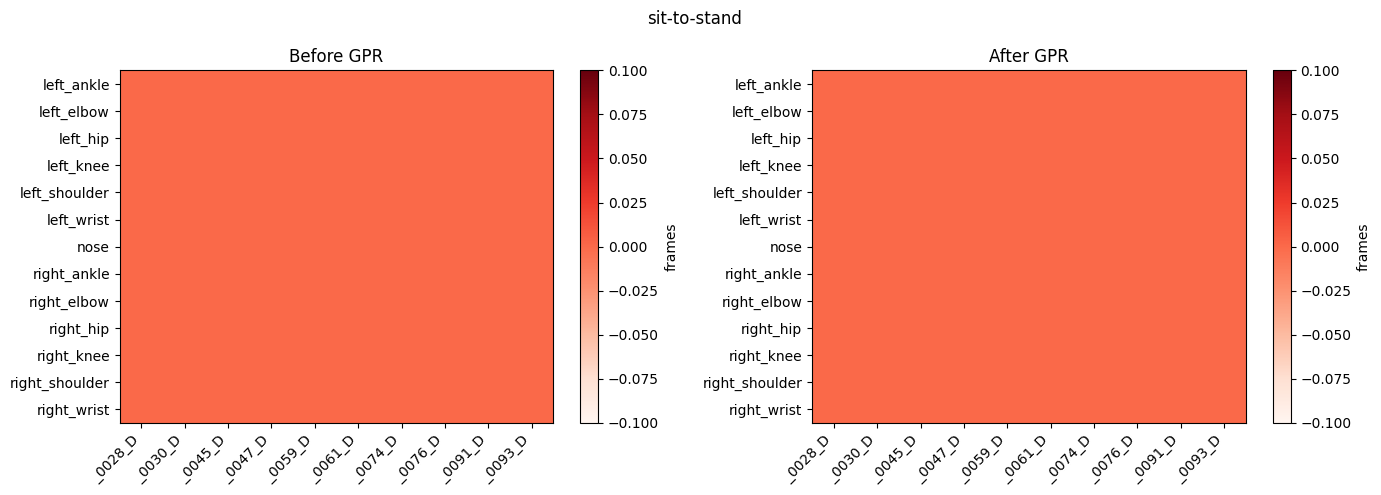


=== stand-to-sit ===
Before: 363 missing frames
After:  0 missing frames
Rescued: 363 (100.0%)
                    video       joint  missing_before  gpr  missing_after  rescued
DJI_20250425092743_0028_D right_elbow               9    9              0        9
DJI_20250425092743_0028_D right_wrist              34   34              0       34
DJI_20250425093100_0030_D right_elbow              39   39              0       39
DJI_20250425104507_0045_D right_elbow              29   29              0       29
DJI_20250425104507_0045_D right_wrist              50   50              0       50
DJI_20250425104804_0047_D right_elbow              50   50              0       50
DJI_20250425112502_0059_D right_elbow               3    3              0        3
DJI_20250425112502_0059_D right_wrist              28   28              0       28
DJI_20250425112749_0061_D right_elbow               5    5              0        5
DJI_20250425112749_0061_D right_wrist               5    5              0 

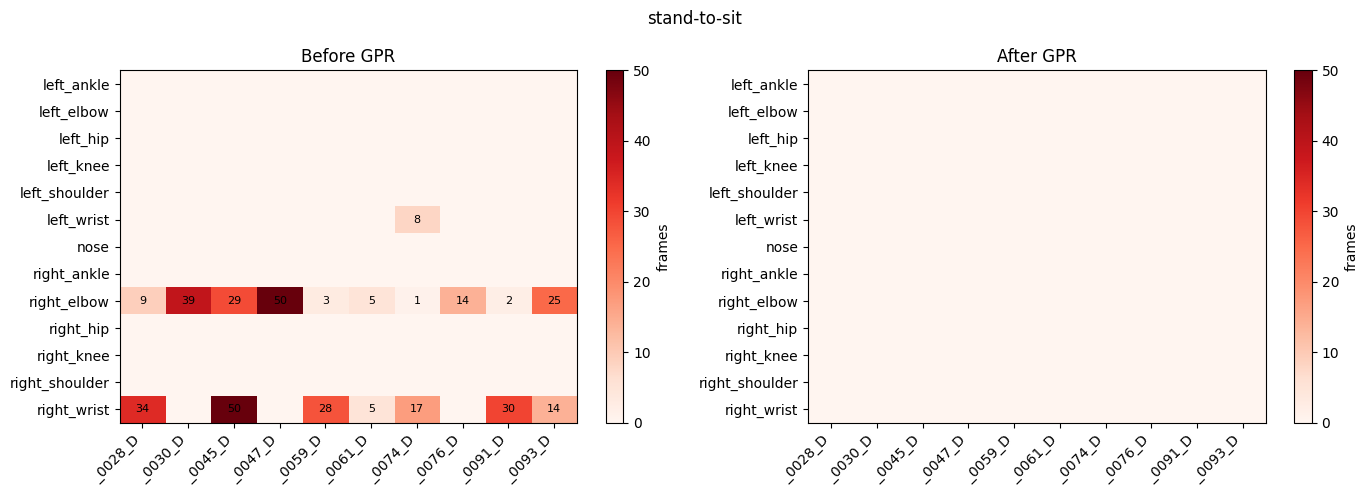

In [48]:
import matplotlib.pyplot as plt

for out_csv, label in [(OUT_CSV, 'sit-to-stand'), (DOWN_OUT_CSV, 'stand-to-sit')]:
    missing_before = missing_before_all[label]
    total_before   = missing_before['missing_before'].sum()

    after_rows = []
    for csv_path in sorted(out_csv.glob('*.csv')):
        df = pd.read_csv(csv_path)
        for joint in JOINTS:
            src_col = f'{joint}_source'
            if src_col not in df.columns:
                continue
            counts = df[src_col].value_counts()
            after_rows.append({
                'video':         csv_path.stem,
                'joint':         joint,
                'missing_after': counts.get('missing', 0),
                'gpr':           counts.get('gpr', 0),
            })

    missing_after = pd.DataFrame(after_rows)
    total_after   = missing_after['missing_after'].sum()

    comp = missing_before.merge(missing_after, on=['video', 'joint'])
    comp['rescued'] = comp['missing_before'] - comp['missing_after']

    print(f'\n=== {label} ===')
    print(f'Before: {total_before} missing frames')
    print(f'After:  {total_after} missing frames')
    print(f'Rescued: {total_before - total_after} ({(total_before - total_after) / max(total_before, 1) * 100:.1f}%)')

    changed = comp[comp['rescued'] != 0][['video', 'joint', 'missing_before', 'gpr', 'missing_after', 'rescued']]
    if changed.empty:
        print('No frames rescued.')
    else:
        print(changed.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(max(8, len(comp['video'].unique()) * 1.4), 5))
    fig.suptitle(label)
    for ax, col, title in zip(axes,
                               ['missing_before', 'missing_after'],
                               ['Before GPR', 'After GPR']):
        pivot = comp.pivot(index='joint', columns='video', values=col).fillna(0).astype(int)
        im = ax.imshow(pivot.values, aspect='auto', cmap='Reds',
                       vmin=0, vmax=comp['missing_before'].max())
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([c[-7:] for c in pivot.columns], rotation=45, ha='right')
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                v = pivot.values[i, j]
                if v > 0:
                    ax.text(j, i, str(v), ha='center', va='center', fontsize=8)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label='frames')

    plt.tight_layout()
    plt.show()